# Machine Learning - Session 6

## Support Vector Machines with `SVC`

The code below creates a simple 2D dataset with two classes.  
We fit a Support Vector Classifier using a pipeline that includes `StandardScaler`, which normalizes the feature values before training. This is important because SVMs are sensitive to feature scale.

`SVC(gamma='auto')` creates a support vector machine with an RBF kernel, which can separate non-linear patterns in the data.

In [3]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X = np.array([[-1, -1], [-2, -1], [1, 1], [2, 1]])
y = np.array([1, 1, 2, 2])
from sklearn.svm import SVC
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])

In [ ]:
print(clf.predict([[-0.8, -1]]))

[1]


The prediction above applies the learned decision boundary to a new sample and returns the class label assigned to that point.

In this example, the model is trying to separate the two groups based on the input coordinates.

### Visualizing the SVC Decision Boundary
Let's visualize how the SVC model separates the two classes. We will create a grid of points, predict their classes, and plot the decision boundary along with the training data.

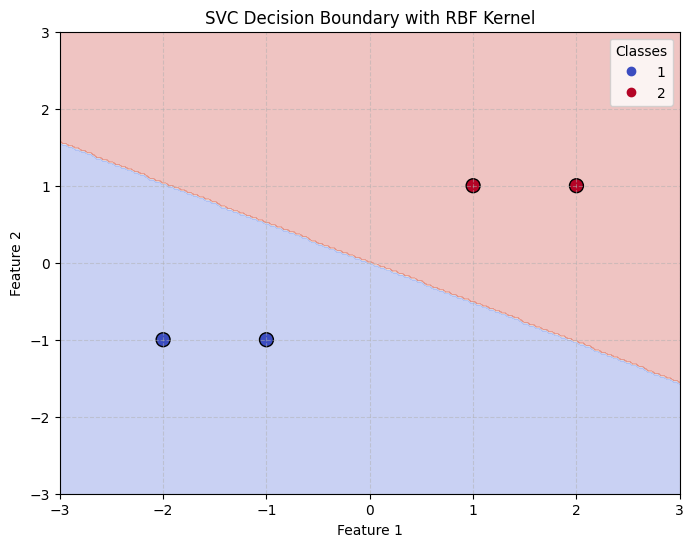

In [4]:
import matplotlib.pyplot as plt

# Create a mesh grid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour and training points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot training points, coloring by class label
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k', cmap=plt.cm.coolwarm)
plt.legend(*scatter.legend_elements(), title="Classes")

plt.title("SVC Decision Boundary with RBF Kernel")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Advanced Examples


#### Linearly Separable Clusters

We can visualize basic linear SVM margins, support vectors, and see how overlapping cluster borders are handled by the $C$ hyperparameter.

Predictions: [1 1]


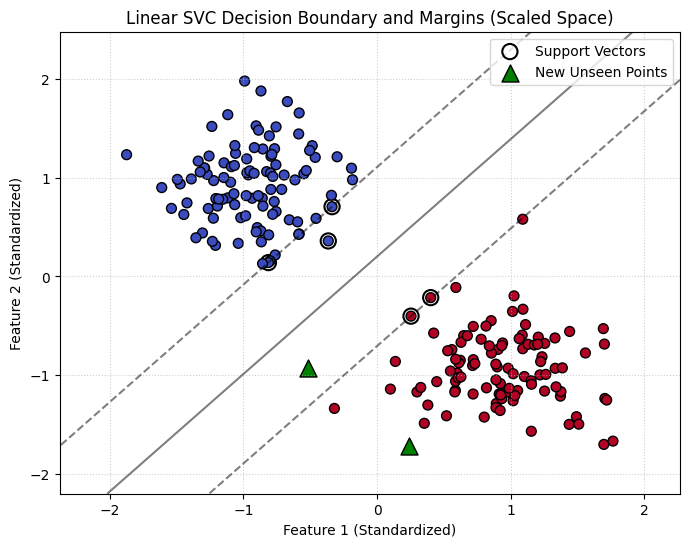

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Generate 200 random samples across 2 classes with controlled overlap (cluster_std)
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=42)

# Train SVM Pipeline
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0))
clf.fit(X, y)

# Predict on new unseen points
new_points = np.array([[-1.0, 2.0], [2.0, -1.0]])
print("Predictions:", clf.predict(new_points))

# --- Visualizing the decision boundary, margins, and support vectors ---
# Retrieve the scaler and the model from pipeline
scaler = clf.named_steps['standardscaler']
model = clf.named_steps['svc']

# Standardize the training data
X_scaled = scaler.transform(X)
new_points_scaled = scaler.transform(new_points)

# Create a mesh grid to plot decision boundary
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Get decision function values for the grid to plot margin contours
xy = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(xy).reshape(xx.shape)

plt.figure(figsize=(8, 6))
# Plot decision boundary (Z=0) and margins (Z=-1, Z=1)
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Highlight Support Vectors
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=120,
            linewidth=1.5, facecolors='none', edgecolors='black', label='Support Vectors')

# Scatter plot of training points
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50)

# Plot new points
plt.scatter(new_points_scaled[:, 0], new_points_scaled[:, 1], c='green', marker='^', s=150, edgecolors='black', label='New Unseen Points')

plt.title("Linear SVC Decision Boundary and Margins (Scaled Space)")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Non-Linear Concentric Circles

We can see how non-linear kernels like RBF (Gaussian) project overlapping data into higher dimensions to draw circular decision boundaries.

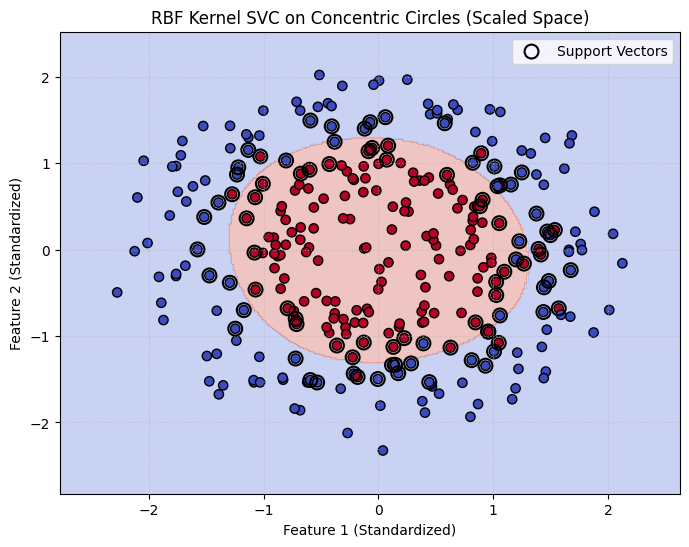

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Generate concentric circles with Gaussian noise
X, y = make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=42)

# Train SVM with RBF Kernel
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', C=1.0))
clf.fit(X, y)

# --- Visualizing the non-linear decision boundary and support vectors ---
scaler = clf.named_steps['standardscaler']
model = clf.named_steps['svc']

# Standardize the data to match the model's feature space
X_scaled = scaler.transform(X)

# Create a mesh grid
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict on mesh grid points to draw colored decision regions
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
# Draw filled contour regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot the raw data points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=45)

# Highlight Support Vectors
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='black', linewidths=1.5, label='Support Vectors')

plt.title("RBF Kernel SVC on Concentric Circles (Scaled Space)")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Interlocking Moons

Great for testing how hyperparameters like `C` and `gamma` adjust model capacity to fit complex, non-linear shapes.

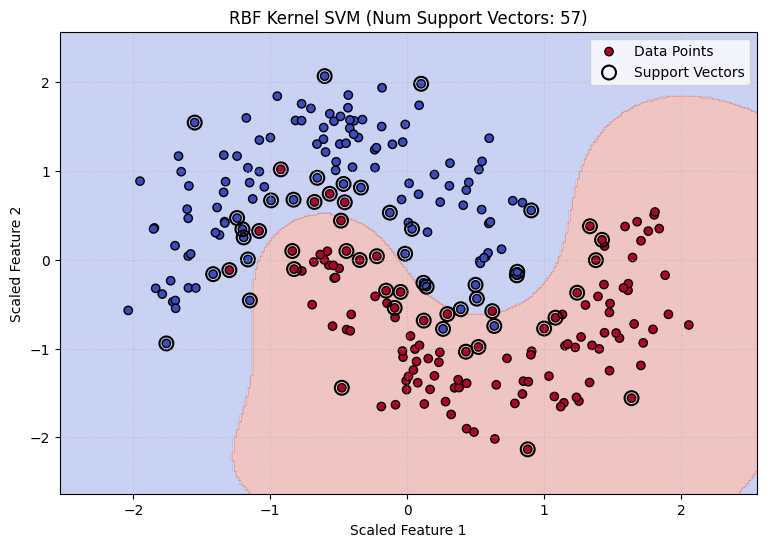

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Generate noisy moons dataset
X, y = make_moons(n_samples=250, noise=0.2, random_state=42)

# 2. Scale features & fit SVM model directly (to inspect support vectors easily)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = SVC(kernel='rbf', gamma=1.0, C=1.0)
model.fit(X_scaled, y)

# 3. Create grid to plot decision boundary
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 4. Plot background boundary, data points, and support vectors
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', label='Data Points')

# Highlight Support Vectors
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

plt.title(f"RBF Kernel SVM (Num Support Vectors: {len(sv)})")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## K-means with `KMeans`

The next example uses the `KMeans` clustering algorithm to partition data into groups based on similarity.  
`n_clusters=2` tells the algorithm to find two centroids and assign each point to the nearest one.

This is an unsupervised learning method, so there are no target labels during training.

In [7]:
from sklearn.cluster import KMeans
import numpy as np
X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
kmeans.labels_

array([1, 1, 1, 0, 0, 0], dtype=int32)

In [8]:
kmeans.predict([[0, 0], [12, 3]])

array([1, 0], dtype=int32)

In [9]:
kmeans.cluster_centers_

array([[10.,  2.],
       [ 1.,  2.]])

The `labels_` array shows which cluster each training point belongs to.  
`predict()` assigns new observations to the nearest cluster center, and `cluster_centers_` reports the final centroid positions learned by the model.

### Visualizing K-means Clusters and Boundaries
Let's visualize the final clusters, their centroids, and the decision boundaries determined by the proximity to each centroid.

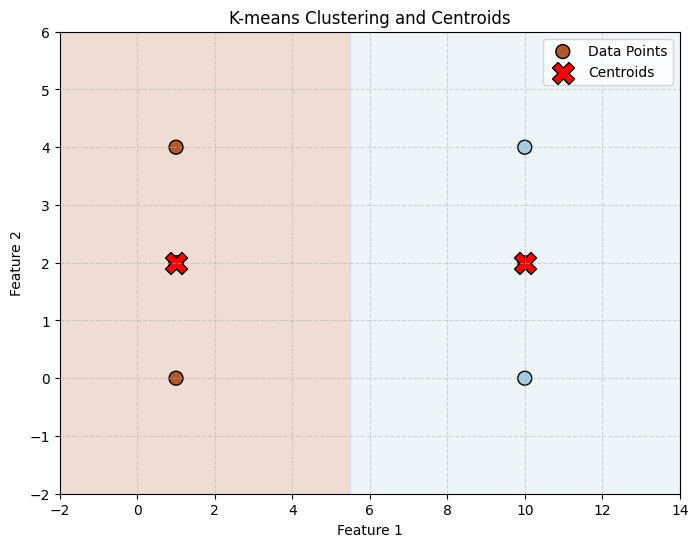

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Create a mesh grid to plot the Voronoi cells (cluster boundaries)
xx_km, yy_km = np.meshgrid(np.linspace(-2, 14, 300), np.linspace(-2, 6, 300))
Z_km = kmeans.predict(np.c_[xx_km.ravel(), yy_km.ravel()])
Z_km = Z_km.reshape(xx_km.shape)

plt.figure(figsize=(8, 6))
# Plot decision boundary region
plt.contourf(xx_km, yy_km, Z_km, alpha=0.2, cmap=plt.cm.Paired)

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=100, edgecolors='k', cmap=plt.cm.Paired, label='Data Points')

# Plot the centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=250, color='red', edgecolors='black', label='Centroids')

plt.title("K-means Clustering and Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Advanced Examples

#### Distinct Gaussian Clusters with Controlled Density

`make_blobs` allows you to set arbitrary cluster counts and adjust `cluster_std` to control how distinct or overlapping the clusters are.

Cluster Centers:
 [[ 4.73821371  1.91399279]
 [-8.65017946  7.48183793]
 [-7.02523244 -6.90932713]
 [-2.62081897  9.10806483]]
Inertia (Sum of squared distances): 1366.4020944062217


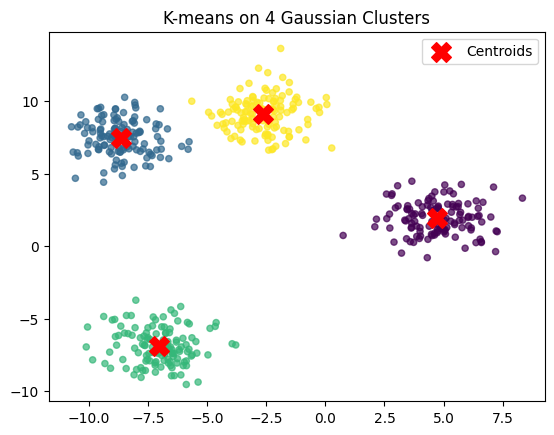

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate 500 samples across 4 clusters with varying dispersion
X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

# Inspect cluster attributes
print("Cluster Centers:\n", kmeans.cluster_centers_)
print("Inertia (Sum of squared distances):", kmeans.inertia_)

# Plot clusters and centroids
plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='viridis', alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red', marker='X', s=200, label='Centroids'
)
plt.title("K-means on 4 Gaussian Clusters")
plt.legend()
plt.show()

#### Anisotropic (Elongated) Clusters

K-means assumes clusters are spherical (isotropic) because it minimizes Euclidean distance. Transforming a dataset with matrix multiplication creates stretched clusters that demonstrate where standard K-means struggles:

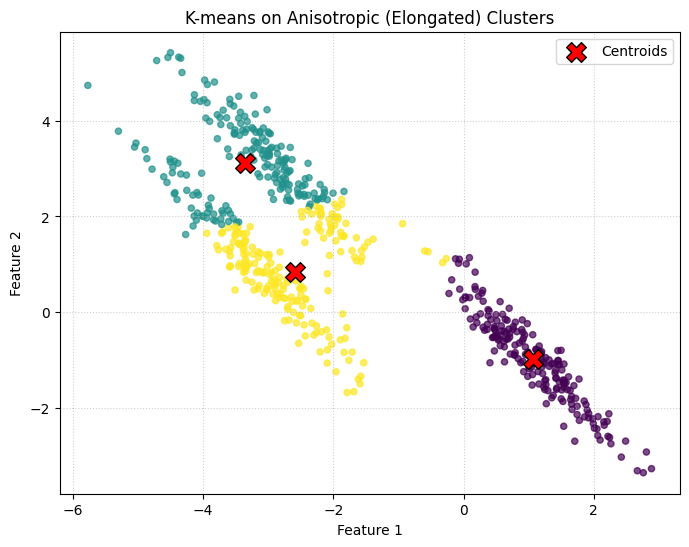

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate standard blobs and stretch them using a linear transformation matrix
X_raw, _ = make_blobs(n_samples=600, centers=3, random_state=170)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X_raw, transformation)

# K-means will split elongated clusters unnaturally because of spherical distance
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(X_aniso)

# Plotting a single, self-contained figure
plt.figure(figsize=(8, 6))
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=kmeans.labels_, s=20, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolors='black')

plt.title("K-means on Anisotropic (Elongated) Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Non-Convex / Non-Spherical Geometry

Running K-means on non-spherical data like crescent shapes illustrates why centroid-based algorithms fail on non-convex geometric boundaries:

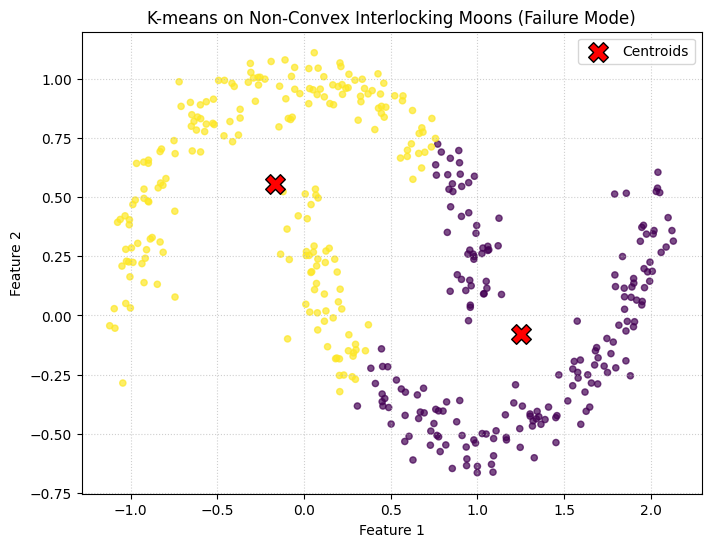

In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons

# Generate interlocking moons
X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=42)

# K-means struggles here because centroids cannot capture non-convex shapes
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init="auto").fit(X_moons)

# Plotting a single, self-contained figure
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons.labels_, s=20, cmap='viridis', alpha=0.7)
plt.scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolors='black')

plt.title("K-means on Non-Convex Interlocking Moons (Failure Mode)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()